In [2]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

from numpy import pi, sqrt
import modules.tools as tools

import os
import pickle

import svgutils.transform as sg
import sys 

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines

import matplotlib.colors as cols
import matplotlib.cm as cm

In [3]:
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band


In [4]:
path = os.path.dirname(os.getcwd()) + '/data/'

In [5]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Main text

## Figure 1 - effective model

In [97]:
# Read in the data - effective Hamiltonian
name = 'effective_hamiltonian'
fb = open(path + name + '.p','rb')

params_heff = pickle.load(fb)
kxs_heff = pickle.load(fb)
energies_nu_heff = pickle.load(fb)
evecs_nu_heff = pickle.load(fb)
energies_an_heff = pickle.load(fb)
density_an_heff = pickle.load(fb)

In [98]:
kxs_neg = -kxs_heff[::-1]
energies_nu_neg = energies_nu_heff[::-1,:]
energies_an_neg = energies_an_heff[::-1,:]

Qx = params_heff['Qx']
Q_bot = params_heff['Q_bot']
Q_top = params_heff['Q_top']
Lz = params_heff['Lz']

zs = np.linspace(-Lz/2, Lz/2, Lz)
k1 = 0
k2 = 104
k3 = 143
k4 = 160

In [99]:
# Read in the data - degeneracy scaling with volume
name = 'degeneracy_scaling'
fb = open(path + name + '.p', 'rb')

params_deg = pickle.load(fb)
Lzs = pickle.load(fb)
spectra_full0 = pickle.load(fb)
spectra_full1 = pickle.load(fb)
n_states_full0 = pickle.load(fb)
n_states_full1 = pickle.load(fb)

In [100]:
n0_lim = params_deg["n0_lim"]

In [101]:
Lx = 2*pi/((params_deg["kxs"])[1] - (params_deg["kxs"])[0])
Ly = 2*pi/((params_deg["kys"])[1] - (params_deg["kys"])[0])

lB = np.sqrt(params_deg["Qx"]*params_deg["R1"])

n_LL = lambda Lz: params_deg["Qx"]*Lx*Ly*Lz/(2*pi* lB**2)/4

In [102]:
print(Q_top)
print(Qx)
print(Q_bot)

0.36720802055783713
0.5053605102841573
0.6031914056096698


In [103]:
kxs_heff[143]

0.5043327648531726

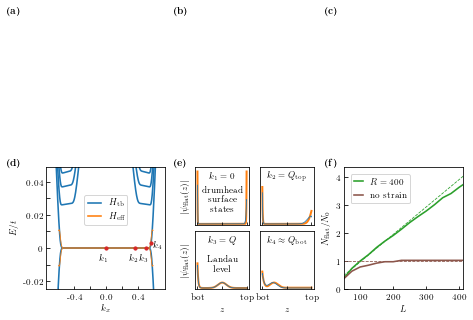

In [104]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

lw = 0.8

fig = plt.figure(figsize=(6.8,4.5))
gs = gridspec.GridSpec(2, 3, wspace=0.25, hspace=0.25, left=0.1, top=0.95, bottom=0.1, right=0.95)

### (a) Nodal line schematic
ax1 = plt.subplot(gs[0,0])
ax1.set_xticks([])
ax1.set_yticks([])
ax1.axis('off')

### (b) cylindrical substrate
ax2 = plt.subplot(gs[0,1])
ax2.set_xticks([])
ax2.set_yticks([])
ax2.axis('off')

### (b) cylindrical substrate
ax3 = plt.subplot(gs[0,2])
ax3.set_xticks([])
ax3.set_yticks([])
ax3.axis('off')

#### (d) Non-interacting spectrum and comparison to effective Hamiltonian

ax4 = plt.subplot(gs[1,0])
plt.plot(kxs_heff, energies_nu_heff[:,0], color=colors[0], lw=2.0*lw, label='$H_\mathrm{tb}$')
plt.plot(kxs_heff, energies_nu_heff, color=colors[0], lw=2.0*lw)
plt.plot(kxs_neg, energies_nu_neg, color=colors[0], lw=2.0*lw)
plt.plot(kxs_heff[0:2], energies_an_heff[0:2,0], color=colors[1], lw=1.0*lw, label='$H_\mathrm{eff}$')
plt.plot(kxs_heff[:-31], energies_an_heff[:-31,:], color=colors[1], lw=1.0*lw)
plt.plot(kxs_neg[31:], energies_an_neg[31:,:], color=colors[1], lw=1.0*lw)
plt.plot(kxs_heff[k1], energies_an_heff[k1,1], color=colors[3], marker='o', ms=4*lw)
plt.plot(kxs_heff[k2], energies_an_heff[k2,1], color=colors[3], marker='o', ms=4*lw)
plt.plot(kxs_heff[k3], energies_an_heff[k3,1], color=colors[3], marker='o', ms=4*lw)
plt.plot(kxs_heff[k4], energies_an_heff[k4,1], color=colors[3], marker='o', ms=4*lw)
#plt.axvline(Qx)
#plt.axvline(Q_bot)
#plt.axvline(Q_top)
plt.xlabel('$k_x$')
plt.ylabel('$E/t$')
plt.ylim(-0.025,0.049)
plt.xlim(-0.75,0.75)
plt.tick_params(direction='in', right=False, top=False)
plt.xticks([-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6],
           ['','-0.4','','0.0','','0.4',''])
plt.yticks([-0.02,-0.01, 0.0, 0.01, 0.02, 0.03, 0.04],
           ['-0.02','','0','','0.02','', '0.04'])
legend_d = plt.legend(loc=10, fontsize=9, handlelength=1.5, bbox_to_anchor=(0.5,0.65))

# set the linewidth of each legend object
for obj in legend_d.legendHandles:
    obj.set_linewidth(2.0*lw)

ax4.text(kxs_heff[k1]-0.08, 0.0-0.008, '$k_1$', fontsize=9)
ax4.text(kxs_heff[k2]-0.08, 0.0-0.008, '$k_2$', fontsize=9)
ax4.text(kxs_heff[k3]-0.08, 0.0-0.008, '$k_3$', fontsize=9)
ax4.text(kxs_heff[k4]+0.03, energies_an_heff[k4,1]-0.003, '$k_4$', fontsize=9)

#### (e) Landau level states and comparison to effective Hamiltonain

ax5 = plt.subplot(gs[1,1])
ax5.axis('off')

inner = gridspec.GridSpecFromSubplotSpec(2, 2,
                    subplot_spec=ax5, wspace=0.2, hspace=0.1)

ax51 = plt.Subplot(fig, inner[0,0])
ax51.plot(zs, sqrt(density_an_heff[k1,:]), color=colors[1], lw=2.5*lw, zorder=-1)                                                                
ax51.plot(zs, sqrt(tools.density(evecs_nu_heff[k1,:,0],2)
                   + tools.density(evecs_nu_heff[k1,:,1],2)), color=colors[0], lw=1.0*lw, zorder=-1)
ax51.set_ylim(-0.02,0.85)
#ax51.set_ylabel(r'$\sqrt{\rho_\mathrm{flat}(z)}$')
ax51.set_ylabel('$|\psi_\mathrm{flat}(z)|$')
ax51.tick_params(direction='in', right=False, top=False)
ax51.set_xticks([-500,0,500])
ax51.set_xticklabels(['','',''])
ax51.set_yticks([])
ax51.text(0, 0.7, '$k_1 = 0$', fontsize=9,
         horizontalalignment='center', verticalalignment='center')
ax51.text(0, 0.35, 'drumhead \n surface \n states', fontsize=9,
         horizontalalignment='center', verticalalignment='center')
fig.add_subplot(ax51)

ax52 = plt.Subplot(fig, inner[0,1])
ax52.plot(zs, sqrt(density_an_heff[k2,:]),color=colors[1], lw=2.5*lw, zorder=-1)                                                                
ax52.plot(zs, sqrt(tools.density(evecs_nu_heff[k2,:,0],2)
                   + tools.density(evecs_nu_heff[k2,:,1],2)), color=colors[0], lw=1.0*lw, zorder=-1)
ax52.set_ylim(-0.02,0.85)
ax52.tick_params(direction='in', right=False, top=False)
ax52.set_xticks([-500,0,500])
ax52.set_xticklabels(['','',''])
ax52.set_yticks([])
ax52.text(0, 0.7, '$k_2 = Q_\mathrm{top}$', fontsize=9,
         horizontalalignment='center', verticalalignment='center')
fig.add_subplot(ax52)

ax53 = plt.Subplot(fig, inner[1,0])  
ax53.plot(zs, sqrt(density_an_heff[k3,:]), color=colors[1], lw=2.5*lw, zorder=-1)                                                                
ax53.plot(zs, sqrt(tools.density(evecs_nu_heff[k3,:,0],2)
                   + tools.density(evecs_nu_heff[k3,:,1],2)), color=colors[0], lw=1.0*lw, zorder=-1)
ax53.set_ylim(-0.02,0.85)
#ax53.set_ylabel(r'$\sqrt{\rho_\mathrm{flat}(z)}$')
ax53.set_ylabel('$|\psi_\mathrm{flat}(z)|$')
ax53.set_xlabel('$z$')
ax53.tick_params(direction='in', right=False, top=False)
ax53.set_xticks([-500,0,500])
ax53.set_xticklabels(['bot','','top'])
ax53.set_yticks([])
ax53.text(0, 0.7, '$k_3 = Q$', fontsize=9,
         horizontalalignment='center', verticalalignment='center')
ax53.text(0, 0.35, 'Landau \n level', fontsize=9,
         horizontalalignment='center', verticalalignment='center')
fig.add_subplot(ax53)

ax54 = plt.Subplot(fig, inner[1,1])
ax54.plot(zs, sqrt(density_an_heff[k4,:]), color=colors[1], lw=2.5*lw, zorder=-1)                                                                
ax54.plot(zs, sqrt(tools.density(evecs_nu_heff[k4,:,0],2)
                   + tools.density(evecs_nu_heff[k4,:,1],2)), color=colors[0], lw=1.0*lw, zorder=-1)
ax54.set_ylim(-0.02,0.85)
ax54.set_xlabel('$z$')
ax54.tick_params(direction='in', right=False, top=False)
ax54.set_xticks([-500,0,500])
ax54.set_xticklabels(['bot','','top'])
ax54.set_yticks([])
ax54.text(0, 0.7, '$k_4 \\approx Q_\mathrm{bot}$', fontsize=9,
         horizontalalignment='center', verticalalignment='center')
fig.add_subplot(ax54)

### (f) Scaling of flat-band degeneracy with volume

ax6 = plt.subplot(gs[1,2])
plt.plot(Lzs, n_states_full1, color=colors[2], lw=2.0*lw, label='$R=400$')
plt.plot(Lzs, n_states_full0, color=colors[5], lw=2.0*lw, label='no strain')
plt.plot(Lzs, n_LL(Lzs), ls='--', lw=lw, color=colors[2])
plt.axhline(n0_lim, ls='--', lw=lw, color=colors[5])
plt.xlabel('$L$')
plt.ylabel('$N_\mathrm{flat}/N_0$')
plt.ylim(0,700)
plt.xlim(50,410)
plt.tick_params(direction='in', right=False, top=False)
plt.xticks([100,200,300,400],
           ['100','200','300','400'])
plt.yticks([0, n0_lim, 2*n0_lim, 3*n0_lim, 4*n0_lim],
           ['0','1','2','3','4'])
plt.legend(loc=2, fontsize=9, handlelength=1.0, bbox_to_anchor=(0.02,0.98))


plt.figtext(0.02, 0.95, r'\textbf{(a)}', fontsize=10)
plt.figtext(0.36, 0.95, r'\textbf{(b)}', fontsize=10)
plt.figtext(0.67, 0.95, r'\textbf{(c)}', fontsize=10)
plt.figtext(0.02, 0.48, r'\textbf{(d)}', fontsize=10)
plt.figtext(0.36, 0.48, r'\textbf{(e)}', fontsize=10)
plt.figtext(0.67, 0.48, r'\textbf{(f)}', fontsize=10)

plt.savefig('figures/figure_1_RAW2.svg')

In [105]:
# use size identical to original svg (must be a string with unit)
size = fig.get_size_inches()
width = str(size[0])+'in' 
height = str(size[0])+'in'

In [106]:
#create new SVG figure
fig_final = sg.SVGFigure(width,height)

# load matpotlib-generated figures
fig1 = sg.fromfile('figures/figure_1_RAW2.svg')
fig2 = sg.fromfile('figures/figure_1_RAW.svg')

# get the plot objects
plot1 = fig1.getroot()
plot2 = fig2.getroot()

# append plots and labels to figure
fig_final.append([plot1, plot2])

# save generated SVG files
fig_final.save("figures/figure_1.svg")

In [107]:
# delete the matplotlib RAW svg files
%rm figures/figure_1_RAW2.svg

## Figure 2 - phase diagram and superfluid stiffness

In [226]:
# Read in the data - Tc curves
name = 'Tc_curves'
fb = open(path + name + '.p','rb')

Cs1 = pickle.load(fb)
Tcs_sc = pickle.load(fb)
Tcs_mag = pickle.load(fb)

In [227]:
N = len(Cs1)
C_crit1 = 2 + np.argmin(abs((Tcs_sc-Tcs_mag)[2:N//2]))
C_crit2 = N//2 + np.argmin(abs((Tcs_sc-Tcs_mag)[N//2:-2]))

In [228]:
# Read in the data - G0/V0-C phase diagram 
name = 'phase_diagram'
fb = open(path + name + '.p','rb')

Cs2 = pickle.load(fb)
Gs_sep = pickle.load(fb)

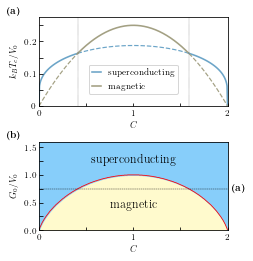

In [229]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

color1 = 'lemonchiffon'
color1d = '#A3A083'
color2 = 'lightskyblue'
color2d = '#6CA5C8'

lw = 0.8

fig = plt.figure(figsize=(3.4,4.0))
gs = gridspec.GridSpec(2, 1, wspace=0.55, hspace=0.4, left=0.13, top=0.92, bottom=0.18, right=0.90)

### (a) Temperature-filling curves
ax1 = plt.subplot(gs[0,0])
plt.plot(Cs1[0:C_crit1], Tcs_sc[0:C_crit1], c=color2d, ls='-', lw=2*lw, label='superconducting', zorder=-1)
plt.plot(Cs1[0:C_crit1], Tcs_mag[0:C_crit1], c=color1d, ls='--', lw=1.5*lw, zorder=-1)
plt.plot(Cs1[C_crit1:C_crit2], Tcs_sc[C_crit1:C_crit2], c=color2d, ls='--', lw=1.5*lw, zorder=-1)
plt.plot(Cs1[C_crit1:C_crit2], Tcs_mag[C_crit1:C_crit2], c=color1d, ls='-', lw=2*lw, label='magnetic', zorder=-1)
plt.plot(Cs1[C_crit2:], Tcs_sc[C_crit2:], c=color2d, ls='-', lw=2*lw, zorder=-1)
plt.plot(Cs1[C_crit2:], Tcs_mag[C_crit2:], c=color1d, ls='--', lw=1.5*lw, zorder=-1)
plt.axvline(Cs1[C_crit1], c='black', lw=0.5*lw, ls=':')
plt.axvline(Cs1[C_crit2], c='black', lw=0.5*lw, ls=':')
plt.xlabel('$C$')
plt.ylabel('$k_B T_c/V_0$')
plt.tick_params(direction='in', right=False, top=False)
plt.xticks([0,0.5,1,1.5,2],
           ['0','','1','','2'])
plt.yticks([0.0, 0.05, 0.1, 0.15, 0.2, 0.25],
           ['0','','0.1','','0.2',''])
plt.xlim(0,2)
plt.ylim(0,0.275)
plt.legend(loc=10, fontsize=9, handlelength=1.0, bbox_to_anchor=(0.5,0.3))

### (b) phase diagram
ax2 = plt.subplot(gs[1,0])
plt.plot(Cs2, Gs_sep, c='red', lw=lw, zorder=-1)
plt.fill_between(Cs2, 0, Gs_sep, color=color1, zorder=-1)
plt.fill_between(Cs2, Gs_sep, 1.6, color=color2, zorder=-1)
plt.axhline(0.75, c='black', lw=0.5*lw, ls='--')
plt.xlabel('$C$')
plt.ylabel('$G_0/V_0$')
plt.tick_params(direction='in', right=False, top=False)
plt.xticks([0,0.5,1,1.5,2],
           ['0','','1','','2'])
plt.yticks([0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5],
           ['0.0','','0.5','','1.0','','1.5'])

plt.xlim(0,2)
plt.ylim(0,1.6)

plt.text(1.0, 1.2, 'superconducting', fontsize=12, fontdict=dict(horizontalalignment='center'))
plt.text(1.0, 0.4, 'magnetic', fontsize=12, fontdict=dict(horizontalalignment='center'))
plt.text(2.05, 0.7, r'\textbf{(a)}', fontsize=10)

plt.figtext(0.0, 0.93, r'\textbf{(a)}', fontsize=10)
plt.figtext(0.0, 0.50, r'\textbf{(b)}', fontsize=10)

plt.savefig('figures/figure_2.svg')

## Figure 3 - materials

In [256]:
# Read in the data - CaAgP bulk bands
name = 'CaAgP_bulk-band_cuts'
fb = open(path + name + '.p','rb')

kzs_CaAgP = pickle.load(fb)
kbulk_CaAgP = pickle.load(fb)
energy_cuts_CaAgP = pickle.load(fb)

In [257]:
# Read in the data - CaAgP LL levels
name = 'CaAgP_LL_spectrum'
fb = open(path + name + '.p','rb')

params_CaAgP = pickle.load(fb)
kline_CaAgP = pickle.load(fb)
energies_CaAgP = pickle.load(fb)
evecs_CaAgP = pickle.load(fb)

In [258]:
# Read in the data - CaAgP bulk bands
name = 'graphite_bulk-band_cuts'
fb = open(path + name + '.p','rb')

kzs_graphite = pickle.load(fb)
kbulk_graphite = pickle.load(fb)
energy_cuts_graphite = pickle.load(fb)

In [259]:
# Read in the data - CaAgP LL levels
name = 'graphite_LL_spectrum'
fb = open(path + name + '.p','rb')

params_graphite = pickle.load(fb)
kline_graphite = pickle.load(fb)
energies_graphite = pickle.load(fb)
evecs_graphite = pickle.load(fb)

In [264]:
Lz_graph = params_graphite['Lz']
k1_graph = 62
evecs1_graph = evecs_graphite[k1_graph,:,0]
evecs2_graph = evecs_graphite[k1_graph,:,1]

In [265]:
Lz_CaAgP = params_CaAgP['Lz']
k1_CaAgP = 72
evecs1_CaAgP = evecs_CaAgP[k1_CaAgP,:,0]
evecs2_CaAgP = evecs_CaAgP[k1_CaAgP,:,1]

In [266]:
density12_graph = tools.density((evecs1_graph + evecs2_graph)/np.sqrt(2),2)
density12_CaAgP = tools.density((evecs1_CaAgP + evecs2_CaAgP)/np.sqrt(2),1)

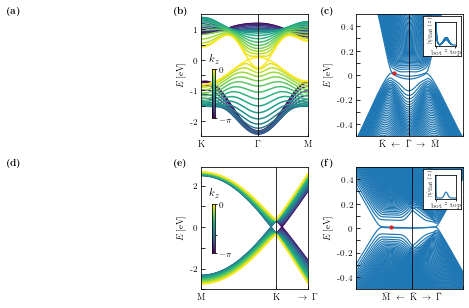

In [272]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

lw = 0.8

fig = plt.figure(figsize=(6.8,4.5))
gs = gridspec.GridSpec(2, 3, wspace=0.45, hspace=0.25, left=0.1, top=0.95, bottom=0.1, right=0.95)

###### CaAgP

### (a) lattice structure and BZ
ax1 = plt.subplot(gs[0,0])
ax1.set_xticks([])
ax1.set_yticks([])
ax1.axis('off')

### (b) bulk bands unstrained
ax2 = plt.subplot(gs[0,1])

cmap2 = plt.get_cmap('viridis') 
cNorm2  = cols.Normalize(vmin=kzs_CaAgP[0], vmax=kzs_CaAgP[-1])
scalarMap2 = cm.ScalarMappable(norm=cNorm2, cmap=cmap2)

for i in range(len(kzs_CaAgP)):
    colorVal2 = scalarMap2.to_rgba(kzs_CaAgP[i])
    plt.plot(kbulk_CaAgP,energy_cuts_CaAgP[i], color=colorVal2, zorder=-1)
plt.axvline(kbulk_CaAgP[100], c='k', lw=lw)
plt.ylim(-2.5,1.5)

plt.xlim(kbulk_CaAgP[0], kbulk_CaAgP[-1])
plt.xticks([kbulk_CaAgP[0],kbulk_CaAgP[100],kbulk_CaAgP[-1]],
           ['K', '$\Gamma$','M'])
plt.yticks([-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0],
           ['-2','','-1','','0','', '1'])
plt.ylabel('$E\,[\mathrm{eV}]$')
plt.tick_params(direction='in', right=False, top=False)

# this is an inset axes over the main axes serving as a colorbar
axins2 = inset_axes(ax2, width="100%", height="100%", loc=6,
                   bbox_to_anchor=(0.05,0.15, 0.05, 0.4),
                   bbox_transform=ax2.transAxes)
cbar2 = np.vstack(kzs_CaAgP)
plt.imshow(cbar2, cmap=cmap2, origin='top' )
axins2.set_title('$k_z$')
axins2.set_xlabel('')
axins2.set_ylabel('')
axins2.tick_params(direction='out', right=True, left=False, top=False, bottom=False, length=2, pad=2)
axins2.xaxis.set_ticks([])
plt.ylim(0,20)
plt.yticks([0, 20],
           ['$-\pi$','0'])
axins2.yaxis.tick_right()

### (c) Landau level plot
ax3 = plt.subplot(gs[0,2])
plt.plot(kline_CaAgP, energies_CaAgP, color=colors[0], lw=1.5*lw, zorder=-3)
#plt.plot(kline_CaAgP[k1_CaAgP], energies_CaAgP[k1_CaAgP,Lz_CaAgP], color=colors[3], marker='o', ms=4*lw)
plt.plot(kline_CaAgP[k1_CaAgP], energies_CaAgP[k1_CaAgP,Lz_CaAgP+1], color=colors[3], marker='o', ms=4*lw, zorder=-2)
plt.axvline(kline_CaAgP[100], c='k', lw=lw, zorder=-1)
plt.ylim(-0.5,0.5)
plt.xlim(kline_CaAgP[0], kline_CaAgP[-1])
plt.xticks([kline_CaAgP[0],kline_CaAgP[100],kline_CaAgP[-1]],
           ['',r'$\bar{\mathrm{K}}$ $\:\leftarrow\:$ $\bar{\Gamma}$ $\:\rightarrow\:$ $\bar{\mathrm{M}}$',''])
plt.yticks([-0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4],
           ['-0.4','','-0.2','','0','','0.2', '', '0.4'])
plt.ylabel('$E\,[\mathrm{eV}]$')
plt.tick_params(direction='in', right=False, top=False)

# this is an inset axes over the main axes
axins3b = inset_axes(ax3, width="100%", height="100%", loc=3,
                   bbox_to_anchor=(0.59,0.62, 0.35, 0.33),
                   bbox_transform=ax3.transAxes)
axins3b.set_xticks([])
axins3b.set_yticks([])

axins3 = inset_axes(ax3, width="100%", height="100%", loc=3,
                   bbox_to_anchor=(0.7,0.7, 0.2, 0.2),
                   bbox_transform=ax3.transAxes)
axins3.plot(np.sqrt(density12_CaAgP), color=colors[0],lw=1.5*lw)
axins3.set_xlabel("$z$", fontsize=6)
axins3.set_ylabel("$|\psi_\mathrm{flat}(z)|$",fontsize=6)
axins3.tick_params(direction='out', right=False, top=False, length=2, pad=2)
axins3.xaxis.set_ticks([0,len(density12_CaAgP)])
axins3.set_xticklabels(['bot','top'], fontsize=6)
axins3.set_yticks([])
axins3.xaxis.set_label_coords(x=0.5, y=-0.03)
axins3.yaxis.set_label_coords(x=-0.05, y=0.7)

### Rhombohedral graphite

#### (d) lattice structure and BZ

ax4 = plt.subplot(gs[1,0])
ax4.set_xticks([])
ax4.set_yticks([])
ax4.axis('off')

#### (e) bulk band structure

ax5 = plt.subplot(gs[1,1])

cmap5 = plt.get_cmap('viridis') 
cNorm5  = cols.Normalize(vmin=kzs_graphite[0], vmax=kzs_graphite[-1])
scalarMap5 = cm.ScalarMappable(norm=cNorm5, cmap=cmap5)

for i in range(len(kzs_graphite)):
    colorVal5 = scalarMap5.to_rgba(kzs_graphite[i])
    plt.plot(kbulk_graphite,energy_cuts_graphite[i], color=colorVal5, zorder=-1)
plt.axvline(kbulk_graphite[400], c='k', lw=lw)
plt.ylim(-2.9,2.9)
plt.xlim(kbulk_graphite[0], kbulk_graphite[-1])
plt.xticks([kbulk_graphite[0],kbulk_graphite[400],kbulk_graphite[-1]],
           ['M', 'K',r'$\:\rightarrow\:\Gamma$'])
plt.yticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0],
           ['','-2','','0','','2'])
plt.ylabel('$E\,[\mathrm{eV}]$')
plt.tick_params(direction='in', right=False, top=False)

# this is an inset axes over the main axes serving as a colorbar
axins5 = inset_axes(ax5, width="100%", height="100%", loc=6,
                   bbox_to_anchor=(0.05,0.3, 0.05, 0.4),
                   bbox_transform=ax5.transAxes)
#axins5.plot(np.sqrt(density12_graph), color=colors[0],lw=1.5*lw)
cbar5 = np.vstack(kzs_graphite)
plt.imshow(cbar5, cmap=cmap5, origin='top')
axins5.set_title('$k_z$')
axins5.set_xlabel('')
axins5.set_ylabel('')
axins5.tick_params(direction='out', right=True, left=False, top=False, bottom=False, length=2, pad=2)
axins5.xaxis.set_ticks([])
plt.ylim(0,20)
plt.yticks([0, 7, 20],
           ['$-\pi$','','0'])
axins5.yaxis.tick_right()

#### (f) Landau levels

ax6 = plt.subplot(gs[1,2])
plt.plot(kline_graphite, energies_graphite, color=colors[0], lw=1.5*lw, zorder=-3)
plt.plot(kline_graphite[k1_graph], energies_graphite[k1_graph,Lz_graph], color=colors[3], marker='o', ms=4*lw, zorder=-2)
plt.axvline(kline_graphite[100], c='k', lw=lw, zorder=-1)
plt.ylim(-0.5,0.5)
plt.xlim(kline_graphite[0], kline_graphite[-1])
plt.xticks([kline_graphite[0],kline_graphite[100],kline_graphite[-1]],
           ['',r'$\bar{\mathrm{M}}$ $\:\leftarrow\:$ $\bar{\mathrm{K}}$ $\:\rightarrow\:\bar{\Gamma}$',''])
plt.yticks([-0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4],
           ['-0.4','','-0.2','','0','','0.2', '', '0.4'])
plt.ylabel('$E\,[\mathrm{eV}]$')
plt.tick_params(direction='in', right=False, top=False)

# this is an inset axes over the main axes
axins6b = inset_axes(ax6, width="100%", height="100%", loc=3,
                   bbox_to_anchor=(0.59,0.62, 0.35, 0.33),
                   bbox_transform=ax6.transAxes)
axins6b.set_xticks([])
axins6b.set_yticks([])

axins6 = inset_axes(ax6, width="100%", height="100%", loc=3,
                   bbox_to_anchor=(0.7,0.7, 0.2, 0.2),
                   bbox_transform=ax6.transAxes)
axins6.plot(np.sqrt(density12_graph), color=colors[0],lw=1.5*lw)
axins6.set_xlabel("$z$", fontsize=6)
axins6.set_ylabel("$|\psi_\mathrm{flat}(z)|$",fontsize=6)
axins6.tick_params(direction='out', right=False, top=False, length=2, pad=2)
axins6.xaxis.set_ticks([0,len(density12_graph)])
axins6.set_xticklabels(['bot','top'], fontsize=6)
axins6.set_yticks([])
axins6.xaxis.set_label_coords(x=0.5, y=-0.03)
axins6.yaxis.set_label_coords(x=-0.05, y=0.7)


plt.figtext(0.02, 0.95, r'\textbf{(a)}', fontsize=10)
plt.figtext(0.36, 0.95, r'\textbf{(b)}', fontsize=10)
plt.figtext(0.66, 0.95, r'\textbf{(c)}', fontsize=10)
plt.figtext(0.02, 0.48, r'\textbf{(d)}', fontsize=10)
plt.figtext(0.36, 0.48, r'\textbf{(e)}', fontsize=10)
plt.figtext(0.66, 0.48, r'\textbf{(f)}', fontsize=10)

plt.savefig('figures/figure_3_RAW2.svg')

In [273]:
# use size identical to original svg (must be a string with unit)
size = fig.get_size_inches()
width = str(size[0])+'in' 
height = str(size[0])+'in'

In [274]:
#create new SVG figure
fig_final = sg.SVGFigure(width,height)

# load matpotlib-generated figures
fig1 = sg.fromfile('figures/figure_3_RAW2.svg')
fig2 = sg.fromfile('figures/figure_3_RAW.svg')

# get the plot objects
plot1 = fig1.getroot()
plot2 = fig2.getroot()

# append plots and labels to figure
fig_final.append([plot1, plot2])

# save generated SVG files
fig_final.save("figures/figure_3.svg")

In [275]:
# delete the matplotlib RAW svg files
%rm figures/figure_3_RAW2.svg

# Supplemental Material

## Figure: Magnetic orders spectra

In [253]:
# Read in the data - effective Hamiltonian
name = 'magnetic_orders_spectra'
fb = open(path + name + '.p','rb')

params = pickle.load(fb)
kxs = pickle.load(fb)
evals0 = pickle.load(fb)
evals1 = pickle.load(fb)
evals2 = pickle.load(fb)
evals3 = pickle.load(fb)
evals4 = pickle.load(fb)

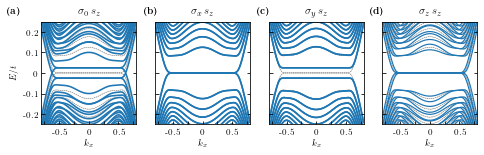

In [255]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

lw = 0.8

fig = plt.figure(figsize=(6.8,2.1))
gs = gridspec.GridSpec(1, 4, wspace=0.20, hspace=0.1, left=0.08, top=0.88, bottom=0.20, right=0.97)

### (a) sz x s0
ax1 = plt.subplot(gs[0,0])
plt.title('$\sigma_0\,s_z$')
plt.plot(kxs, evals0, color='gray', ls='--', lw=0.5*lw, zorder=-2)
plt.plot(kxs, evals1, color=colors[0], lw=2.0*lw, zorder=-1)
plt.xlabel('$k_x$')
plt.ylabel('$E/t$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([-0.75,-0.5,-0.25,0.0,0.25,0.5,0.75],
           ['','-0.5','','0','','0.5',''])
plt.yticks([-0.2,-0.1,0.0,0.1,0.2],
           ['-0.2','-0.1','0','0.1','0.2'])

### (b) sz x sx
ax2 = plt.subplot(gs[0,1])
plt.title('$\sigma_x\,s_z$')
plt.plot(kxs, evals0, color='gray', ls='--', lw=0.5*lw, zorder=-2)
plt.plot(kxs, evals2, color=colors[0], lw=2.0*lw, zorder=-1)
plt.xlabel('$k_x$')
#plt.ylabel('$E/t$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([-0.75,-0.5,-0.25,0.0,0.25,0.5,0.75],
           ['','-0.5','','0','','0.5',''])
plt.yticks([-0.2,-0.1,0.0,0.1,0.2],
           [])

### (c) sz x sy
ax3 = plt.subplot(gs[0,2])
plt.title('$\sigma_y\,s_z$')
plt.plot(kxs, evals0, color='gray', ls='--', lw=0.5*lw, zorder=-2)
plt.plot(kxs, evals3, color=colors[0], lw=2.0*lw, zorder=-1)
plt.xlabel('$k_x$')
#plt.ylabel('$E/t$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([-0.75,-0.5,-0.25,0.0,0.25,0.5,0.75],
           ['','-0.5','','0','','0.5',''])
plt.yticks([-0.2,-0.1,0.0,0.1,0.2],
           [])

#### (d) sz x sz

ax4 = plt.subplot(gs[0,3])
plt.title('$\sigma_z\,s_z$')
plt.plot(kxs, evals0, color='gray', ls='--', lw=0.5*lw, zorder=-2)
plt.plot(kxs, evals4, color=colors[0], lw=1.5*lw, zorder=-1)
plt.xlabel('$k_x$')
#plt.ylabel('$E/t$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([-0.75,-0.5,-0.25,0.0,0.25,0.5,0.75],
           ['','-0.5','','0','','0.5',''])
plt.yticks([-0.2,-0.1,0.0,0.1,0.2],
           [])


plt.figtext(0.01, 0.93, r'\textbf{(a)}', fontsize=10)
plt.figtext(0.29, 0.93, r'\textbf{(b)}', fontsize=10)
plt.figtext(0.52, 0.93, r'\textbf{(c)}', fontsize=10)
plt.figtext(0.75, 0.93, r'\textbf{(d)}', fontsize=10)

plt.savefig('figures/figure_SM_magnetic_spectra.svg')

## Figure: phase diagrams of mean-field solutions

In [46]:
# Read in the data - ferromagnetic order

path = os.path.dirname(os.getcwd()) + '/data/'
name = 'ferromagnetic_meanfield_C_T'
fb = open(path + name + '.p','rb')  
params1 = pickle.load(fb)
Cs1 = pickle.load(fb)
Ts1 = pickle.load(fb)
mzs1 = pickle.load(fb)
mus1 = pickle.load(fb)
errs1 = pickle.load(fb)

In [47]:
# Read in the data - superconducting order

path = os.path.dirname(os.getcwd()) + '/data/'
name = 'superconducting_meanfield_C_T'
fb = open(path + name + '.p','rb')  
params2 = pickle.load(fb)
Cs2 = pickle.load(fb)
Ts2 = pickle.load(fb)
Deltas2 = pickle.load(fb)
mus2 = pickle.load(fb)
errs2 = pickle.load(fb)

In [48]:
Cs3 = np.linspace(0.0,2.0,100)

def Tc_fm(C):
    return 0.25*C*(2.-C)

def Tc_sc(C):
    if C==1.0:
        return 1/4
    elif C==0.0:
        return 0.0
    elif C==2.0:
        return 0.0
    else:
        return 1/4 * (1-C)/np.arctanh(1-C)

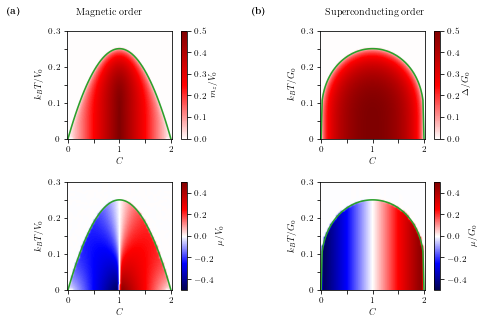

In [49]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

cmap1 = 'seismic'

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=-1):
    if n == -1:
        n = cmap.N
    new_cmap = cols.LinearSegmentedColormap.from_list(
         'trunc({name},{a:.2f},{b:.2f})'.format(name=cmap.name, a=minval, b=maxval),
         cmap(np.linspace(minval, maxval, n)))
    return new_cmap

minColor = 0.5
maxColor = 1.0
cmap2 = truncate_colormap(plt.get_cmap(cmap1), minColor, maxColor)

lw = 0.8

fig = plt.figure(figsize=(6.8,4.5))
gs = gridspec.GridSpec(2, 2, wspace=0.35, hspace=0.4, left=0.05, top=0.9, bottom=0.1, right=0.95)

### (a) ferromagnetic order

### mzs
ax1 = plt.subplot(gs[0,0])
plt.imshow(abs(mzs1).transpose(), extent=tools.imshow_extent(Cs1,Ts1), 
           aspect=7, origin='lower', interpolation='Gaussian', vmin=0.0, vmax=0.5, cmap=cmap2)
plt.plot(Cs3, Tc_fm(Cs3), c=colors[2], lw=2*lw)
plt.xlabel('$C$')
plt.ylabel('$k_BT/V_0$')
plt.ylim(0.0,0.3)
plt.xticks([0.0,0.5,1.0,1.5,2.0],
           ['0','','1','','2'])
plt.yticks([0.0,0.05,0.1,0.15,0.2,0.25,0.3],
           ['0','','0.1','','0.2','','0.3'])

plt.colorbar(label='$m_z/V_0$')

### mus
ax2 = plt.subplot(gs[1,0])
plt.imshow(mus1.transpose(), extent=tools.imshow_extent(Cs1,Ts1), 
           aspect=7, origin='lower', interpolation='Gaussian', vmin=-0.5, vmax=0.5, cmap=cmap1)
plt.plot(Cs3, Tc_fm(Cs3), c=colors[2], lw=2*lw)
plt.xlabel('$C$')
plt.ylabel('$k_BT/V_0$')
plt.ylim(0.0,0.3)
plt.xticks([0.0,0.5,1.0,1.5,2.0],
           ['0','','1','','2'])
plt.yticks([0.0,0.05,0.1,0.15,0.2,0.25,0.3],
           ['0','','0.1','','0.2','','0.3'])
plt.colorbar(label='$\mu/V_0$')

### (b) superconducting order

### deltas
ax3 = plt.subplot(gs[0,1])
plt.imshow(abs(Deltas2).transpose(), extent=tools.imshow_extent(Cs2,Ts2), 
           aspect=7, origin='lower', interpolation='Gaussian', vmin=0.0, vmax=0.5, cmap=cmap2)
plt.plot(Cs3, np.array([Tc_sc(C) for C in Cs3]), c=colors[2], lw=2*lw)
plt.xlabel('$C$')
plt.ylabel('$k_BT/G_0$')
plt.ylim(0.0,0.3)
plt.xticks([0.0,0.5,1.0,1.5,2.0],
           ['0','','1','','2'])
plt.yticks([0.0,0.05,0.1,0.15,0.2,0.25,0.3],
           ['0','','0.1','','0.2','','0.3'])
plt.colorbar(label='$\Delta/G_0$')

### mus
ax4 = plt.subplot(gs[1,1])
plt.imshow(mus2.transpose(), extent=tools.imshow_extent(Cs2,Ts2), 
           aspect=7, origin='lower', interpolation='Gaussian', vmin=-0.5, vmax=0.5, cmap=cmap1)
plt.plot(Cs3, np.array([Tc_sc(C) for C in Cs3]), c=colors[2], lw=2*lw)
plt.xlabel('$C$')
plt.ylabel('$k_BT/G_0$')
plt.ylim(0.0,0.3)
plt.xticks([0.0,0.5,1.0,1.5,2.0],
           ['0','','1','','2'])
plt.yticks([0.0,0.05,0.1,0.15,0.2,0.25,0.3],
           ['0','','0.1','','0.2','','0.3'])
plt.colorbar(label='$\mu/G_0$')


plt.figtext(0.02, 0.95, r'\textbf{(a)}', fontsize=10)
plt.figtext(0.52, 0.95, r'\textbf{(b)}', fontsize=10)

plt.figtext(0.16, 0.95, 'Magnetic order', fontsize=10)
plt.figtext(0.67, 0.95, 'Superconducting order', fontsize=10)

plt.savefig('figures/figure_SM_phase_diagrams.svg')

## Figure: Superfluid Stiffness

In [5]:
# Read in the data - toy model
name = 'toy_model_stiffness_scaling'
fb = open(path + name + '.p','rb')

params_toy = pickle.load(fb)
Lzs_toy = pickle.load(fb)
energies0_toy = pickle.load(fb)
energies1_toy = pickle.load(fb)
energies3_toy = pickle.load(fb)
gij0_toy = pickle.load(fb)
gij1_toy = pickle.load(fb)
gij2_toy = pickle.load(fb)
Dij0_toy = pickle.load(fb)
Dij1_toy = pickle.load(fb)
Dij2_toy = pickle.load(fb)

In [6]:
t1 = params_toy['t1_1']
t2 = params_toy['t2']
R = params_toy['R1']

Q = sqrt(t1)
l0 = sqrt(t2*R)
lD = sqrt(R*Q)

scaling_factor = pi/2 * (lD/l0)**2 *Q

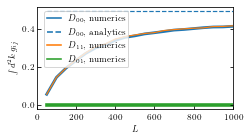

In [9]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

lw = 0.8

fig = plt.figure(figsize=(6.8,2.1))
gs = gridspec.GridSpec(1, 1, left=0.3, top=0.88, bottom=0.20, right=0.7)

###
ax1 = plt.subplot(gs[0,0])
plt.plot(Lzs_toy, Dij1_toy[:,0,0], color=colors[0], lw=3.5*lw, zorder=-2, label='$D_{00}$, numerics')
plt.plot(Lzs_toy, Lzs_toy*scaling_factor, color=colors[0], ls='--', lw=1.5*lw, zorder=-2, label='$D_{00}$, analytics')
plt.plot(Lzs_toy, Dij1_toy[:,1,1], color=colors[1], lw=1.5*lw, zorder=-2, label='$D_{11}$, numerics')
plt.plot(Lzs_toy, Dij1_toy[:,0,1], color=colors[2], lw=4.5*lw, zorder=-2, label='$D_{01}$, numerics')


plt.xlabel('$L$')
plt.ylabel('$\int d^2 k\, g_{ij}$')
plt.ylim(0,590)
plt.xlim(0,1000)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([0,200,400,600,800,1000],
           ['0','200','400','600','800','1000'])
plt.yticks([0,100,200,300,400,500],
           ['0','100','200','300','400','500'])

legend_d = plt.legend(loc=1, fontsize=9, handlelength=1.5, bbox_to_anchor=(0.49,1.0))

# set the linewidth of each legend object
for obj in legend_d.legendHandles:
    obj.set_linewidth(2.0*lw)
    
plt.savefig('figures/figure_SM_stiffness_scaling.svg')

## Figure: Scaling of magnetic interaction V0

In [8]:
# Read in the data - effective Hamiltonian
name = 'magnetic_V0_scaling'
fb = open(path + name + '.p','rb')

params = pickle.load(fb)
Rs = pickle.load(fb)
V0s = pickle.load(fb)

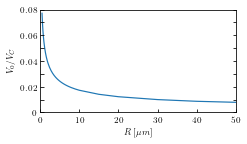

In [20]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

lw = 0.8

fig = plt.figure(figsize=(6.8,2.1))
gs = gridspec.GridSpec(1, 1, left=0.3, top=0.88, bottom=0.20, right=0.7)

###
ax1 = plt.subplot(gs[0,0])
plt.plot(Rs, V0s, color=colors[0], lw=1.5*lw, zorder=-2)
plt.xlabel('$R\,[\mu m]$')
plt.ylabel('$V_0/V_C$')
plt.ylim(0,0.08)
plt.xlim(0,50)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([0,10,20,30,40,50],
           ['0','10','20','30','40','50'])
plt.yticks([0,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08],
           ['0','','0.02','','0.04','','0.06','','0.08'])

plt.savefig('figures/figure_SM_magnetic_V0_scaling.svg')

## Figure: Additional sp strain term

In [41]:
# Read in the data - spectra

name = 'spectrum_strained_Lx100_Lz100_R20000_without_sp'
fb = open(path + name + '.p','rb')
params_save0 = pickle.load(fb)
kys0 = pickle.load(fb)
evals0 = pickle.load(fb)

name = 'spectrum_strained_Lx100_Lz100_R200_without_sp'
fb = open(path + name + '.p','rb')
params_save1 = pickle.load(fb)
kys1 = pickle.load(fb)
evals1 = pickle.load(fb)

name = 'spectrum_strained_Lx100_Lz100_R200_with_sp'
fb = open(path + name + '.p','rb')
params_save2 = pickle.load(fb)
kys2 = pickle.load(fb)
evals2 = pickle.load(fb)

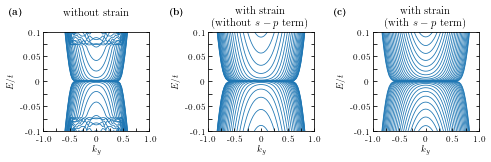

In [45]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

lw = 0.4

fig = plt.figure(figsize=(6.8,2.3))
gs = gridspec.GridSpec(1, 3, wspace=0.55, hspace=0.1, left=0.08, top=0.80, bottom=0.20, right=0.97)

### (a) without strain
ax1 = plt.subplot(gs[0,0])
plt.title('without strain', pad=15)
plt.plot(kys0, evals0, color=colors[0], lw=2.0*lw, zorder=-1)
plt.xlabel('$k_y$')
plt.ylabel('$E/t$')
plt.ylim(-0.1,0.1)
plt.xlim(-1.0,1.0)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([-1.0,-0.75,-0.5,-0.25,0.0,0.25,0.5,0.75,1.0],
           ['-1.0','','-0.5','','0','','0.5','','1.0'])
plt.yticks([-0.1,-0.075,-0.05,-0.025,0.0,0.025,0.05,0.075,0.1],
           ['-0.1','','-0.05','','0','','0.05','','0.1'])

### (b) with strain, without sp term
ax2 = plt.subplot(gs[0,1])
plt.title('with strain\n (without $s-p$ term)')
plt.plot(kys1, evals1, color=colors[0], lw=2.0*lw, zorder=-1)
plt.xlabel('$k_y$')
plt.ylabel('$E/t$')
plt.ylim(-0.1,0.1)
plt.xlim(-1.0,1.0)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([-1.0,-0.75,-0.5,-0.25,0.0,0.25,0.5,0.75,1.0],
           ['-1.0','','-0.5','','0','','0.5','','1.0'])
plt.yticks([-0.1,-0.075,-0.05,-0.025,0.0,0.025,0.05,0.075,0.1],
           ['-0.1','','-0.05','','0','','0.05','','0.1'])

### (c) sz x sy
ax3 = plt.subplot(gs[0,2])
plt.title('with strain\n (with $s-p$ term)')
plt.plot(kys2, evals2, color=colors[0], lw=2.0*lw, zorder=-1)
plt.xlabel('$k_y$')
plt.ylabel('$E/t$')
plt.ylim(-0.1,0.1)
plt.xlim(-1.0,1.0)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([-1.0,-0.75,-0.5,-0.25,0.0,0.25,0.5,0.75,1.0],
           ['-1.0','','-0.5','','0','','0.5','','1.0'])
plt.yticks([-0.1,-0.075,-0.05,-0.025,0.0,0.025,0.05,0.075,0.1],
           ['-0.1','','-0.05','','0','','0.05','','0.1'])

plt.figtext(0.01, 0.90, r'\textbf{(a)}', fontsize=10)
plt.figtext(0.34, 0.90, r'\textbf{(b)}', fontsize=10)
plt.figtext(0.675, 0.90, r'\textbf{(c)}', fontsize=10)

plt.savefig('figures/figure_SM_additional_sp_term.svg')

## Figure: Large flat band

In [9]:
# Read in the data

name = 'minimal_model_largeQ'
fb = open(path + name + '.p','rb')
params = pickle.load(fb)
kline = pickle.load(fb)
energies = pickle.load(fb)
evecs = pickle.load(fb)
S = pickle.load(fb)

In [53]:
S_cut = (S>200)*0.7
kxs = params['kxs']
kys = params['kys']

i=40
state1 = np.sqrt(tools.density(evecs[i,:,0],2))
state2 = np.sqrt(tools.density(evecs[i,:,1],2))

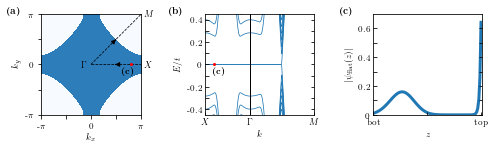

In [108]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=9)

lw = 0.5

fig = plt.figure(figsize=(6.8,2.0))
gs = gridspec.GridSpec(1, 3, wspace=0.55, hspace=0.1, left=0.06, top=0.90, bottom=0.20, right=0.97)

### (a) Fermi surface
ax1 = plt.subplot(gs[0,0])
plt.imshow(S_cut.transpose(), extent=tools.imshow_extent(kxs,kys), aspect=1, cmap='Blues',
           vmin=0, vmax=1.0, interpolation='none')

plt.plot(kxs[100:], kxs[100:], 'k--', lw=1.5*lw)
ax1.annotate('', xy=[pi/2,pi/2], xytext=[pi*0.48,pi*0.48],
    arrowprops={'arrowstyle': '-|>', 'color': 'k', 'shrinkA': 0, 'shrinkB': 0})
plt.plot(kxs[100:], 0*kxs[100:], 'k--', lw=1.5*lw)
ax1.annotate('', xy=[pi/2,0], xytext=[pi*0.48,0],
    arrowprops={'arrowstyle': '<|-', 'color': 'k', 'shrinkA': 0, 'shrinkB': 0})

plt.plot([pi-kline[i]],[0], c='red', ls='', marker='.', ms=4)
ax1.text(pi-kline[i]-0.2*pi, -0.2*pi, r'\textbf{(c)}')

plt.xlabel('$k_x$')
plt.ylabel('$k_y$')
plt.tick_params(direction='out', right=False, top=False)
plt.xticks([-pi,-pi/2,0,pi/2,pi],
           ['-$\pi$','','0','','$\pi$'])
plt.yticks([-pi,-pi/2,0,pi/2,pi],
           ['-$\pi$','','0','','$\pi$'])

### (b) spectrum
ax2 = plt.subplot(gs[0,1])
plt.plot(kline, energies, color=colors[0], lw=1.5*lw, zorder=-1)
plt.plot([kline[i]],[0], c='red', ls='', marker='.', ms=4)
ax2.text(kline[i]-0.05*pi, -0.09, r'\textbf{(c)}')

plt.axvline(kline[200],c='k',lw=1)
plt.xlabel('$k$')
plt.ylabel('$E/t$')
plt.ylim(-0.45,0.45)
plt.xlim(kline[0],kline[-1])
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([0,kline[200],kline[-1]],
           ['$X$','$\Gamma$','$M$'])
plt.yticks([-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4],
           ['-0.4','','-0.2','','0','','0.2','','0.4'])

### (c) state
ax3 = plt.subplot(gs[0,2])
plt.plot(state1, color=colors[0], lw=6.0*lw, zorder=-2)
#plt.plot(state2, color=colors[1], lw=3.0*lw, zorder=-1)
plt.xlabel('$z$')
plt.ylabel('$|\psi_{\mathrm{flat}}(z)|$')
plt.ylim(0,0.7)
plt.xlim(0,100)
plt.tick_params(direction='in', right=True, top=False)
plt.xticks([0,49,99],
           ['bot','','top'])
plt.yticks([0,0.1,0.2,0.3,0.4,0.5,0.6],
           ['0','','0.2','','0.4','','0.6'])

plt.figtext(0.0, 0.90, r'\textbf{(a)}', fontsize=10)
plt.figtext(0.33, 0.90, r'\textbf{(b)}', fontsize=10)
plt.figtext(0.68, 0.90, r'\textbf{(c)}', fontsize=10)

ax1.text(1.05*pi, -0.05*pi, '$X$')
ax1.text(-0.2*pi, -0.05*pi, '$\Gamma$')
ax1.text(1.05*pi, 0.95*pi, '$M$')

plt.savefig('figures/figure_SM_large_flat_band.svg')